In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nb_functions import read_proc_data

### Load processed datasets

In [2]:
X_train, X_val, X_test, train_target, val_target, test_target = read_proc_data()

In [3]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(97988, 118)
(17089, 118)
(25710, 118)


In [4]:
print(train_target.shape)
print(val_target.shape)
print(test_target.shape)

(97988,)
(17089,)
(25710,)


### Training using Decision Trees

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
model = DecisionTreeClassifier(random_state=42)

In [7]:
%%time
model.fit(X_train, train_target)

CPU times: total: 5.53 s
Wall time: 5.91 s


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Model Evaluation

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [9]:
train_preds = model.predict(X_train)

In [10]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(97988,), dtype=object)

In [11]:
train_target

0         No
1         No
2         No
3         No
4         No
          ..
144548    No
144549    No
144550    No
144551    No
144552    No
Name: RainTomorrow, Length: 97988, dtype: str

In [12]:
accuracy_score(train_preds, train_target)

0.9999795893374699

99% of the training data was correctly predicted by the model. Possible overfitting

In [13]:
train_proba = model.predict_proba(X_train)
train_proba

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(97988, 2))

Evaluate the model using validation data  
Metric: accuracy score

In [14]:
model.score(X_val, val_target)

0.7936684416876353

79% of the validation data was correctly predicted.  
High variance between the training(99%) and validation(79%) error.  
Overfitting exists

#### Model Visualization

In [15]:
from sklearn.tree import plot_tree, export_text

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.346\nsamples = 97988\nvalue = [76190, 21798]'),
 Text(0.25, 0.625, 'Humidity3pm <= 0.512\ngini = 0.244\nsamples = 81588\nvalue = [69975, 11613]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.525\ngini = 0.142\nsamples = 47657\nvalue = [43985.0, 3672.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'WindGustSpeed <= 0.333\ngini = 0.359\nsamples = 33931\nvalue = [25990, 7941]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.471\nsamples = 16400\nvalue = [6215, 10185]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Rainfall <= 0.007\ngini = 0.499\nsamples = 9053\nvalue = [4772, 4281]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Rainfall <= 0.009\ngini = 0.316\nsamples = 7347\nvalue = [1443, 5904]'),
 Text(0.8125, 0.125, 

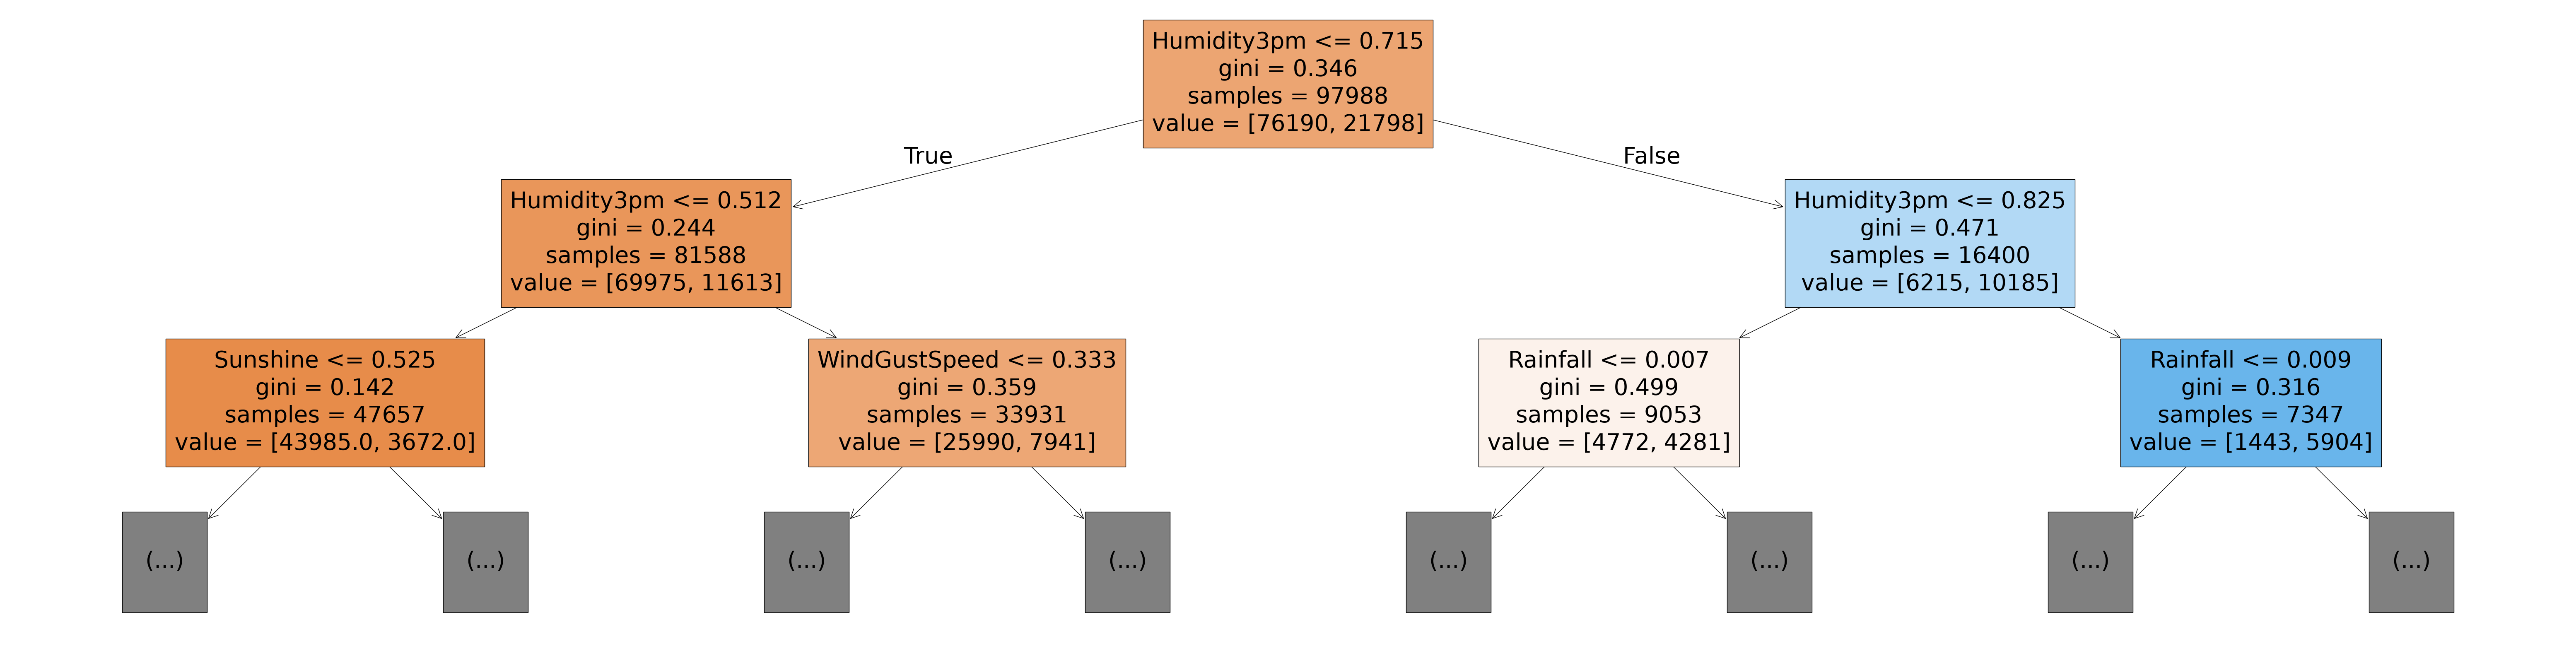

In [16]:
plt.figure(figsize=(80, 20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True)

In [17]:
model.tree_.max_depth

49

The decision tree built by the model grew to a depth of 49 levels

Displaying the decision tree as text

In [18]:
tree_text = export_text(model, max_depth=10, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.51
|   |   |--- Sunshine <= 0.53
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- Pressure3pm <= 0.44
|   |   |   |   |   |--- Humidity3pm <= 0.24
|   |   |   |   |   |   |--- WindGustDir_N <= 0.50
|   |   |   |   |   |   |   |--- WindSpeed9am <= 0.32
|   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.44
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.06
|   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.06
|   |   |   |   |   |   |   |   |   |   |--- Temp9am <= 0.65
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- Temp9am >  0.65
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |--- Pressure3pm >  0.44
|   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |--- WindSpeed9am >  0.32
|   |   |   |   |   |   |   | 

#### Feature Importance

In [19]:
model.feature_importances_

array([3.72348864e-02, 3.02750170e-02, 4.46807871e-02, 2.31016443e-02,
       4.74029876e-02, 6.02158346e-02, 2.59596261e-02, 2.87123098e-02,
       3.72718924e-02, 2.78696714e-01, 3.74751640e-02, 6.22463592e-02,
       1.50293521e-02, 1.72695492e-02, 3.51997396e-02, 3.28171151e-02,
       2.07437921e-03, 1.64079963e-03, 1.01783054e-03, 6.88212657e-04,
       1.48034667e-03, 1.10335980e-03, 1.19280342e-03, 1.77001797e-03,
       8.18956871e-04, 1.30986391e-03, 8.00314193e-04, 2.03677225e-03,
       1.38645663e-03, 4.84888047e-04, 6.08349928e-04, 1.26483304e-03,
       1.45258514e-04, 1.50514431e-03, 1.07182434e-03, 1.44829853e-03,
       9.12938347e-04, 8.15936194e-04, 1.26468932e-03, 1.49092396e-03,
       6.60526489e-04, 7.09652768e-04, 1.02344514e-03, 1.54844869e-03,
       1.31824900e-03, 6.07286685e-04, 5.04774518e-04, 1.50976724e-03,
       1.36782184e-03, 2.12844007e-03, 1.24769141e-03, 1.92047622e-03,
       1.46145581e-03, 2.12670031e-03, 1.36401119e-03, 4.10431985e-04,
      

In [20]:
X_train.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm',
       ...
       'WindDir3pm_SE', 'WindDir3pm_SSE', 'WindDir3pm_SSW', 'WindDir3pm_SW',
       'WindDir3pm_W', 'WindDir3pm_WNW', 'WindDir3pm_WSW', 'WindDir3pm_nan',
       'RainToday_No', 'RainToday_Yes'],
      dtype='str', length=118)

In [21]:
# Dataframe to view the importance of the columns
importance_df = pd.DataFrame({
  'feature': X_train.columns, 
  'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

Top ten predictors of raining the next day

In [22]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.278697
11,Pressure3pm,0.062246
5,WindGustSpeed,0.060216
4,Sunshine,0.047403
2,Rainfall,0.044681
10,Pressure9am,0.037475
8,Humidity9am,0.037272
0,MinTemp,0.037235
14,Temp9am,0.035200
15,Temp3pm,0.032817


In [23]:
importance_df.tail(10)

,feature,importance
19,Location_AliceSprings,0.000688
40,Location_Newcastle,0.000661
30,Location_GoldCoast,0.000608
45,Location_PearceRAAF,0.000607
46,Location_Penrith,0.000505
29,Location_Darwin,0.000485
55,Location_Townsville,0.000410
64,Location_Woomera,0.000405
57,Location_Uluru,0.000235
32,Location_Katherine,0.000145


Text(0.5, 1.0, 'Feature Importance')

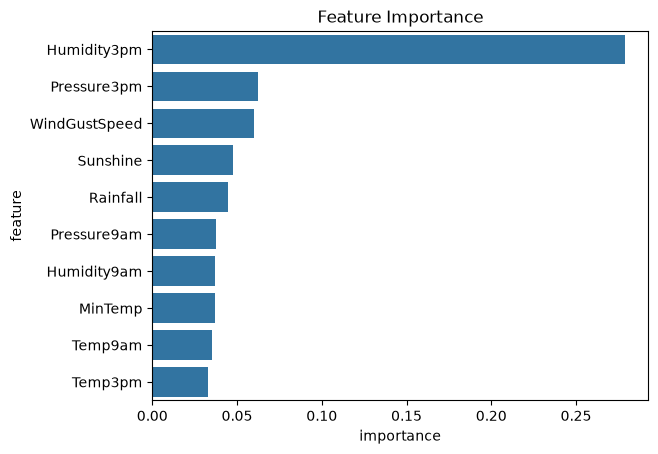

In [24]:
sns.barplot(importance_df.head(10), x='importance', y='feature')
plt.title('Feature Importance')

### DT Hyperparameter Tuning and Overfitting

Overfitting: The model achieved 100% training accuracy while validation accuracy(79%) was only marginally better than a dumb baseline model(77%)

##### Tune max_depth for the model

In [25]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [26]:
model.fit(X_train, train_target)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [27]:
model.score(X_train, train_target)

0.8315916234640977

In [28]:
model.score(X_val, val_target)

0.8348060155655685

Training Accuracy: 100 -> 83  
Validation Accuracy: 79 -> 83

Accuracy score of the validation data improves from 79% to 83% while training drops from 100% to 83%  
The model is able to learn the pattern in the data instead of memorizing the values

In [29]:
model.classes_

array(['No', 'Yes'], dtype=object)

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.346\nsamples = 97988\nvalue = [76190, 21798]\nclass = No'),
 Text(0.25, 0.625, 'Humidity3pm <= 0.512\ngini = 0.244\nsamples = 81588\nvalue = [69975, 11613]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.525\ngini = 0.142\nsamples = 47657\nvalue = [43985.0, 3672.0]\nclass = No'),
 Text(0.0625, 0.125, 'gini = 0.335\nsamples = 6010\nvalue = [4731, 1279]\nclass = No'),
 Text(0.1875, 0.125, 'gini = 0.108\nsamples = 41647\nvalue = [39254, 2393]\nclass = No'),
 Text(0.375, 0.375, 'WindGustSpeed <= 0.333\ngini = 0.359\nsamples = 33931\nvalue = [25990, 7941]\nclass = No'),
 Text(0.3125, 0.125, 'gini = 0.304\nsamples = 27841\nvalue = [22637, 5204]\nclass = No'),
 Text(0.4375, 0.125, 'gini = 0.495\nsamples = 6090\nvalue = [3353, 2737]\nclass = No'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.471\nsamples = 16400\nvalue = [6215, 10185]\nclass = Yes'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Rainf

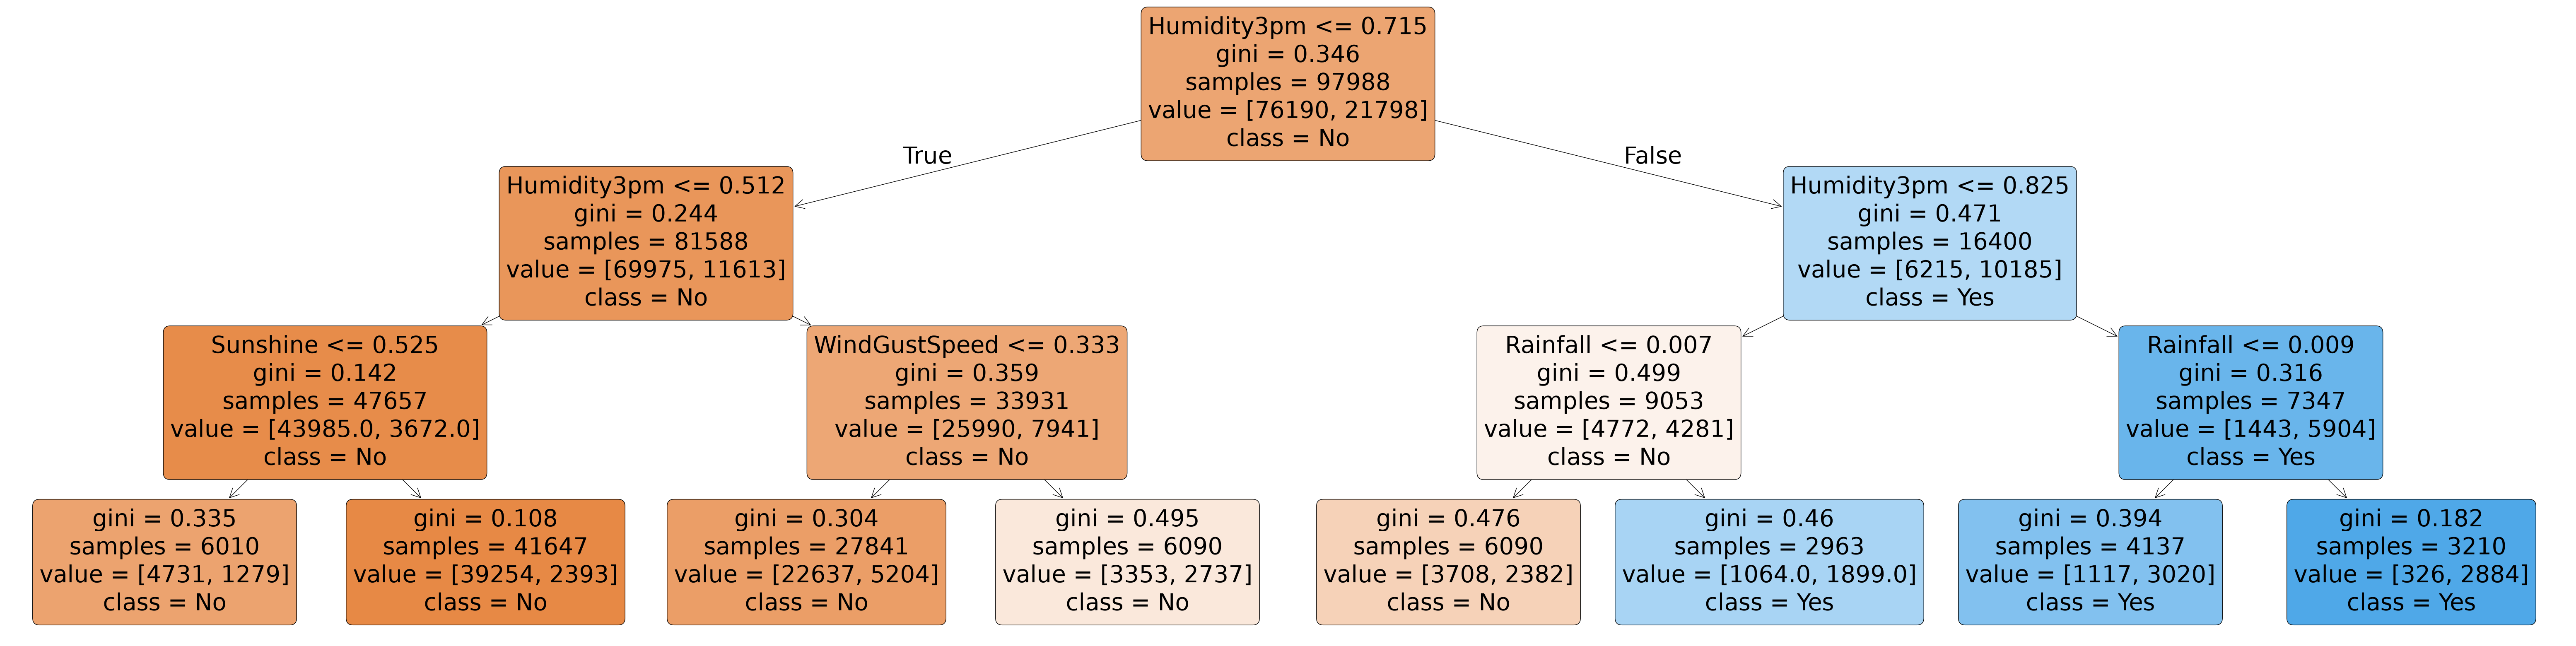

In [30]:
plt.figure(figsize=(80, 20))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_)

In [31]:
print(export_text(model, feature_names=list(X_train.columns)))

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.51
|   |   |--- Sunshine <= 0.53
|   |   |   |--- class: No
|   |   |--- Sunshine >  0.53
|   |   |   |--- class: No
|   |--- Humidity3pm >  0.51
|   |   |--- WindGustSpeed <= 0.33
|   |   |   |--- class: No
|   |   |--- WindGustSpeed >  0.33
|   |   |   |--- class: No
|--- Humidity3pm >  0.72
|   |--- Humidity3pm <= 0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- class: No
|   |   |--- Rainfall >  0.01
|   |   |   |--- class: Yes
|   |--- Humidity3pm >  0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- class: Yes
|   |   |--- Rainfall >  0.01
|   |   |   |--- class: Yes



Function to evaluate different tree depths

In [32]:
def max_depth_error(md):
  model = DecisionTreeClassifier(max_depth=md, random_state=42)
  model.fit(X_train, train_target)
  train_error = 1 - model.score(X_train, train_target)
  val_error = 1 - model.score(X_val, val_target)
  return {'Max Depth': md, 'Training Error': train_error, 'Validation Error': val_error}

In [33]:
%%time
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

CPU times: total: 52.4 s
Wall time: 55.7 s


In [34]:
errors_df

,Max Depth,Training Error,Validation Error
0,1,0.181941,0.176488
1,2,0.176930,0.170695
2,3,0.168408,0.165194
3,4,0.162153,0.161624
4,5,0.157244,0.158113
5,6,0.153131,0.155831
6,7,0.149059,0.154602
7,8,0.144814,0.153842
8,9,0.139435,0.154544
9,10,0.131802,0.154778


Looking at the maximum depth that produces the least validation error, there is 8 followed by 7 levels

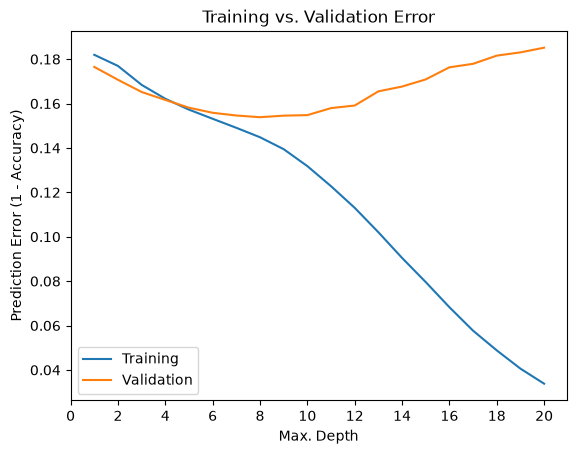

In [35]:
# Plot the errors_df showing Training vs. Validation error
plt.plot(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0, 21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])
plt.show()

From the plot it appears that a maximum depth of 7 results in the lowest validation error

In [36]:
model = DecisionTreeClassifier(max_depth=7, random_state=42).fit(X_train, train_target)
model.score(X_train, train_target), model.score(X_val, val_target)

(0.8509409315426378, 0.8453976242027035)

Try with a max. depth of 8 

In [37]:
model = DecisionTreeClassifier(max_depth=8, random_state=42).fit(X_train, train_target)
model.score(X_train, train_target), model.score(X_val, val_target)

(0.8551863493488998, 0.8461583474749839)

A model trained with a maximum depth of 8 or 7 levels produces similar estimates  

Training Accuracy: 83 -> 85  
Validation Accuracy: 83 -> 84

In [38]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 8,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

##### Tune max_leaf_nodes

In [39]:
model = DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [40]:
model.fit(X_train, train_target)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",128
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [41]:
model.score(X_train, train_target)

0.852696248520227

In [42]:
model.score(X_val, val_target)

0.8471531394464276

In [43]:
model.tree_.max_depth

11

In [44]:
model_text = export_text(model, feature_names=list(X_train.columns))
print(model_text[:3000])

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.51
|   |   |--- Sunshine <= 0.53
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- Pressure3pm <= 0.44
|   |   |   |   |   |--- Humidity3pm <= 0.24
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  0.24
|   |   |   |   |   |   |--- Sunshine <= 0.37
|   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |--- Sunshine >  0.37
|   |   |   |   |   |   |   |--- class: No
|   |   |   |   |--- Pressure3pm >  0.44
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  0.28
|   |   |   |   |   |   |--- Cloud3pm <= 0.39
|   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |--- Cloud3pm >  0.39
|   |   |   |   |   |   |   |--- Location_Hobart <= 0.50
|   |   |   |   |   |   |   |   |--- WindGustSpeed <= 0.23
|   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |--- WindGustSpeed >  0.23

Evaluate model performance using different values for hyperparameters, max_depth and max_leaf_nodes

In [45]:
def mod_model_hparam(n):
  results = []
  for i in range(1, n+1):
    for j in range(2, n+1):
      model = DecisionTreeClassifier(max_depth=i, max_leaf_nodes=j, random_state=42)
      model.fit(X_train, train_target)
      train_error = 1 - model.score(X_train, train_target)
      val_error = 1 - model.score(X_val, val_target)
      results.append({'Max Depth': i, 'Max Leaf Nodes': j, 'Training Error' : train_error, 'Validation Error': val_error})
  
  results_df = pd.DataFrame(results)
  return results_df

In [46]:
# Call the function to get a dataframe with the max. depth and leaf nodes and corresponding training and validation error
res_df = mod_model_hparam(10)

In [47]:
res_df.sort_values(by='Validation Error').head(10)

,Max Depth,Max Leaf Nodes,Training Error,Validation Error
52,6,9,0.163551,0.161390
61,7,9,0.163551,0.161390
43,5,9,0.163551,0.161390
34,4,9,0.163551,0.161390
79,9,9,0.163551,0.161390
88,10,9,0.163551,0.161390
70,8,9,0.163551,0.161390
35,4,10,0.162153,0.161624
71,8,10,0.162153,0.161624
44,5,10,0.162153,0.161624


With a max. depth of either 4 to 10 levels and max. leaf nodes of 9 the model is able to learn all the general patterns from the data

In [48]:
model = DecisionTreeClassifier(max_depth=8, max_leaf_nodes=10, random_state=42).fit(X_train, train_target)
model.score(X_train, train_target), model.score(X_val, val_target)

(0.837847491529575, 0.8383755632278074)

The model is not able to capture all the patterns with the values used.  
It performs worse than when there is no value for max_leaf_nodes, validation error drops from 84 to 83

Best decision tree model - Parameter -> max_depth=8:  
Training accuracy: 85%  
Validation accuracy: 84%

### Training a Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
model = RandomForestClassifier(n_jobs=-1, random_state=42)

In [51]:
%%time
model.fit(X_train, train_target)

CPU times: total: 51.6 s
Wall time: 16.1 s


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

#### Model Evaluation

In [52]:
# Random forest accuracy score on training data
model.score(X_train, train_target)

0.9999693840062048

In [53]:
# Accuracy score on validation data
model.score(X_val, val_target)

0.8567499561121189

Overfitting:  
Training accuracy = 99%  
Validation accuracy = 85%

In [54]:
# Probability of the predictions
train_proba = model.predict_proba(X_train)
train_proba

array([[0.96, 0.04],
       [0.98, 0.02],
       [0.98, 0.02],
       ...,
       [1.  , 0.  ],
       [0.99, 0.01],
       [0.94, 0.06]], shape=(97988, 2))

In [55]:
# Categories being predicted
model.classes_

array(['No', 'Yes'], dtype=object)

In [56]:
# Access individual decision trees
model.estimators_[0]

,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1608637542
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number 

[Text(0.5, 0.875, 'Sunshine <= 0.403\ngini = 0.344\nsamples = 61960\nvalue = [76344, 21644]'),
 Text(0.25, 0.625, 'Location_Cairns <= 0.5\ngini = 0.499\nsamples = 11206\nvalue = [9273, 8335]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Rainfall <= 0.007\ngini = 0.498\nsamples = 10799\nvalue = [9032, 7934]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'WindDir9am_nan <= 0.5\ngini = 0.469\nsamples = 407\nvalue = [241, 401]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'RainToday_Yes <= 0.5\ngini = 0.276\nsamples = 50754\nvalue = [67071, 13309]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Humidity9am <= 0.675\ngini = 0.203\nsamples = 41293\nvalue = [57901, 7511]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Temp3pm <= 0.383\ngini = 0.475\nsamples = 9461\nvalue = [9170, 5798]'),
 Text(0.8125, 0.125, '\n  (...

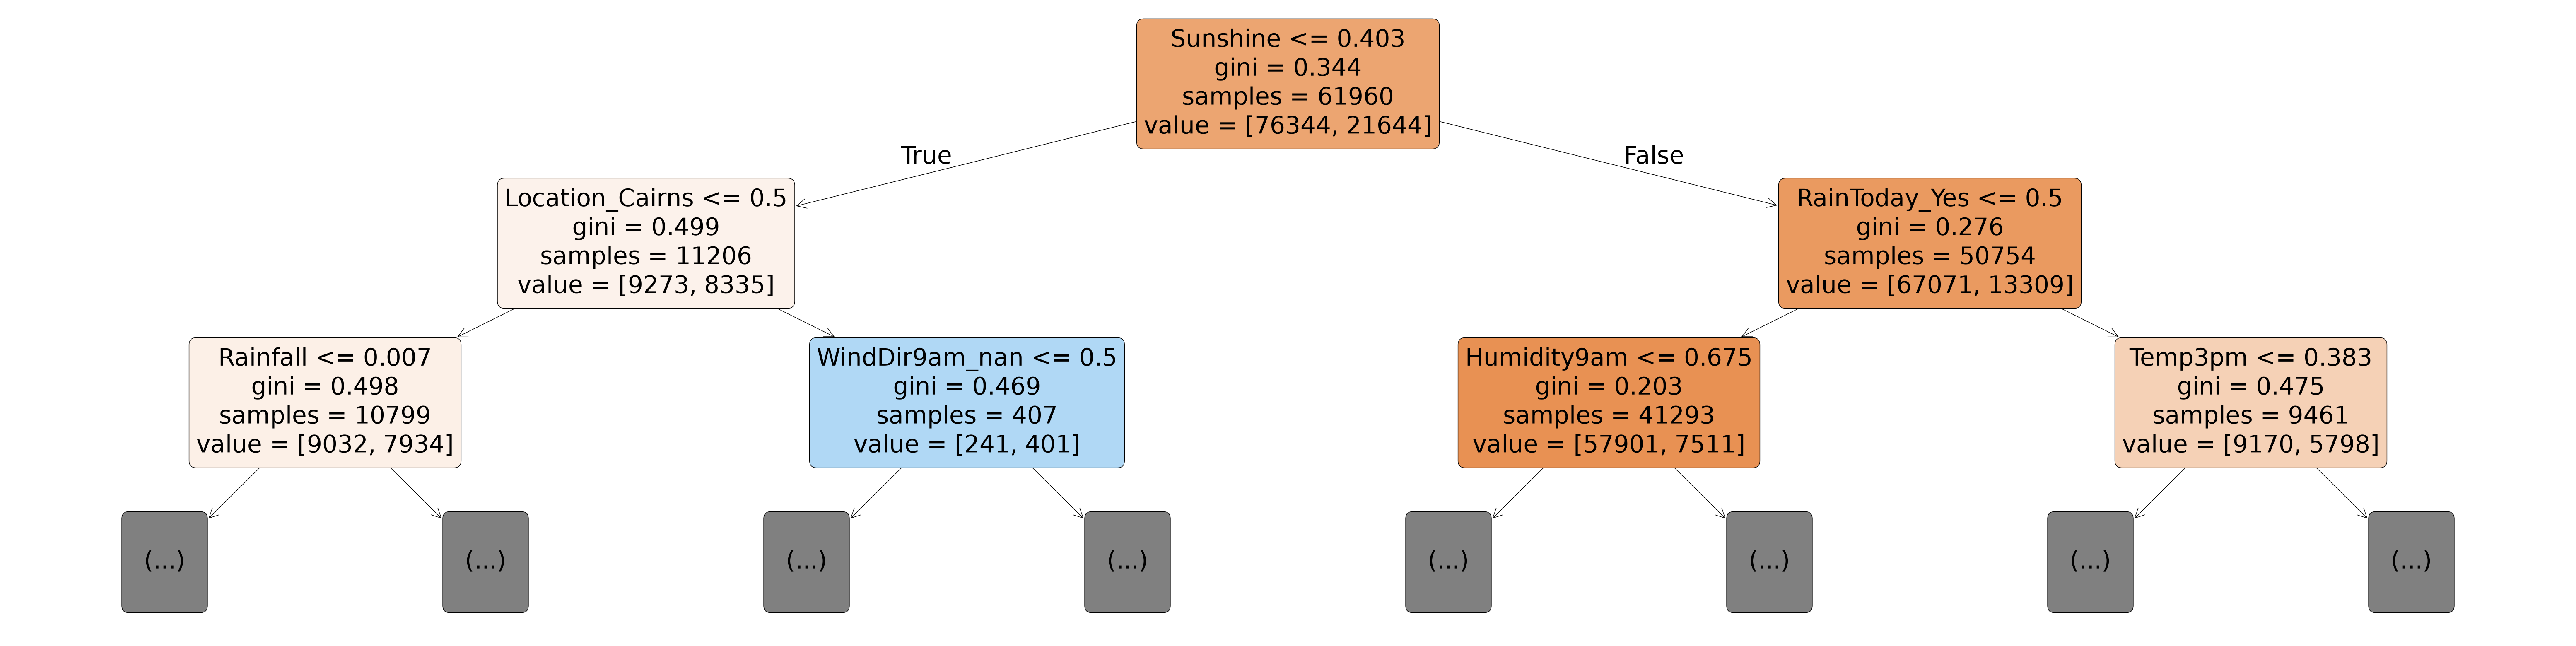

In [57]:
plt.figure(figsize=(80, 20))
plot_tree(model.estimators_[0], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True)

[Text(0.5, 0.875, 'RainToday_Yes <= 0.5\ngini = 0.348\nsamples = 61980\nvalue = [76040, 21948]'),
 Text(0.25, 0.625, 'Humidity9am <= 0.695\ngini = 0.259\nsamples = 48100\nvalue = [64388, 11594]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'WindGustSpeed <= 0.38\ngini = 0.197\nsamples = 28238\nvalue = [39743, 4946]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'MaxTemp <= 0.328\ngini = 0.335\nsamples = 19862\nvalue = [24645, 6648]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Cloud9am <= 0.389\ngini = 0.498\nsamples = 13880\nvalue = [11652, 10354]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Cloud3pm <= 0.722\ngini = 0.331\nsamples = 1644\nvalue = [2061, 545]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'WindSpeed3pm <= 0.351\ngini = 0.5\nsamples = 12236\nvalue = [9591, 9809]'),
 Text(0.8125, 0.125, '\n  (

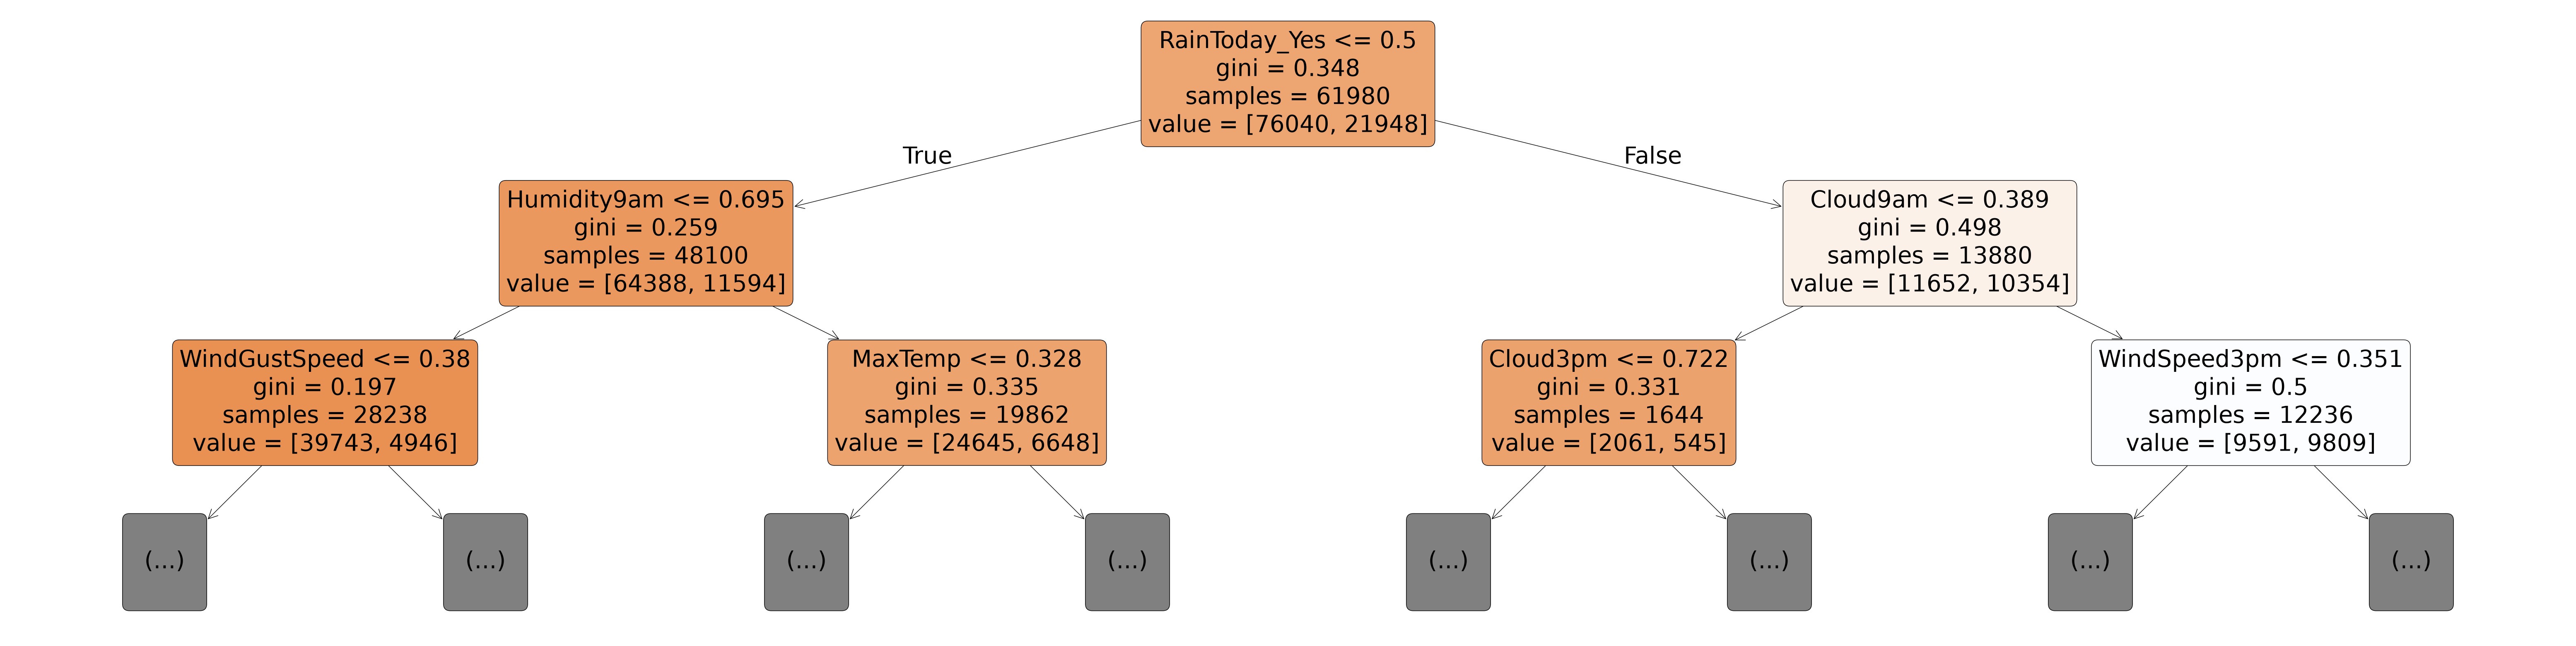

In [58]:
plt.figure(figsize=(80, 20))
plot_tree(model.estimators_[20], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True)

In [59]:
model.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=1608637542),
 DecisionTreeClassifier(max_features='sqrt', random_state=1273642419),
 DecisionTreeClassifier(max_features='sqrt', random_state=1935803228),
 DecisionTreeClassifier(max_features='sqrt', random_state=787846414),
 DecisionTreeClassifier(max_features='sqrt', random_state=996406378),
 DecisionTreeClassifier(max_features='sqrt', random_state=1201263687),
 DecisionTreeClassifier(max_features='sqrt', random_state=423734972),
 DecisionTreeClassifier(max_features='sqrt', random_state=415968276),
 DecisionTreeClassifier(max_features='sqrt', random_state=670094950),
 DecisionTreeClassifier(max_features='sqrt', random_state=1914837113),
 DecisionTreeClassifier(max_features='sqrt', random_state=669991378),
 DecisionTreeClassifier(max_features='sqrt', random_state=429389014),
 DecisionTreeClassifier(max_features='sqrt', random_state=249467210),
 DecisionTreeClassifier(max_features='sqrt', random_state=1972458954),
 DecisionTreeC

Individual Decision Trees(Avg. of 78%) have a lower accuracy score than the Random Forest(85%)

In [60]:
for i in model.estimators_:
  mod = i.fit(X_train, train_target)
  print(mod.score(X_val, val_target))

0.7853590028673416
0.7913277546960032
0.78963075662707
0.7862367604892035
0.7885189303060448
0.782608695652174
0.78963075662707
0.7855345543917139
0.7891041020539529
0.7862952776639944
0.7892796535783252
0.7899818596758148
0.7853004856925507
0.7840716250219439
0.7888700333547897
0.7910351688220493
0.7903329627245597
0.788460413131254
0.7892211364035344
0.7879337585581369
0.7872315524606472
0.7948387851834513
0.7851834513429692
0.7902744455497689
0.7836620047984083
0.7879337585581369
0.7876996898589737
0.7829012815261279
0.7878167242085552
0.7848323482942243
0.7886359646556265
0.7896892738018608
0.7855345543917139
0.7869389665866932
0.7805605945344959
0.786119726139622
0.7813213178067763
0.7899818596758148
0.790215928374978
0.7809116975832406
0.7835449704488268
0.7844227280706888
0.7817894552051027
0.7881093100825092
0.7862367604892035
0.7889870677043712
0.7892796535783252
0.790215928374978
0.7841886593715256
0.7876996898589737
0.7916203405699573
0.787582655509392
0.7860026917900403
0.7

#### Feature Importance

In [61]:
importance_df = pd.DataFrame({
  'feature': X_train.columns, 
  'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.133932
4,Sunshine,0.061397
11,Pressure3pm,0.053715
8,Humidity9am,0.051243
10,Pressure9am,0.049701
2,Rainfall,0.048065
5,WindGustSpeed,0.047550
15,Temp3pm,0.045981
1,MaxTemp,0.042437
0,MinTemp,0.042341


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

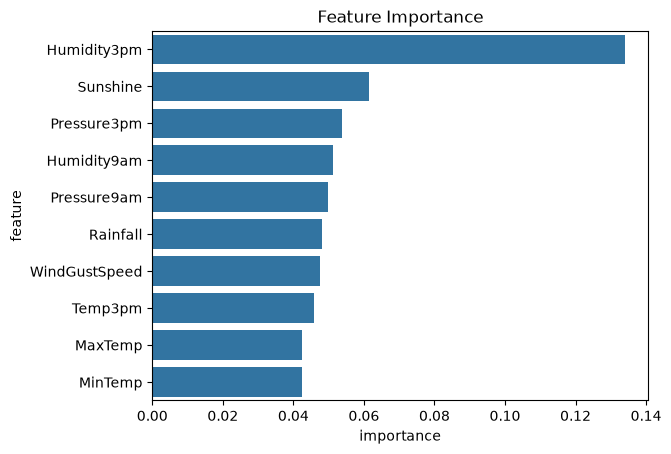

In [62]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')

### RF Hyperparameter Tuning

In [63]:
base_model = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train, train_target)

In [64]:
base_train_acc = base_model.score(X_train, train_target)
base_val_acc = base_model.score(X_val, val_target)

In [65]:
base_accs = base_train_acc, base_val_acc
base_accs

(0.9999693840062048, 0.8567499561121189)

#### Tune n_estimators

In [66]:
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=10)

In [67]:
# Accuracy score with 10 decision trees(n_estimators=10)
model.fit(X_train, train_target)
model.score(X_train, train_target), model.score(X_val, val_target)

(0.9869882026370576, 0.8447539352800046)

With 10 decision trees - Still overfitting:  
Training score: 98%  
Validation score: 84%

In [68]:
# Accuracy score with 500 decision trees
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=500)
model.fit(X_train, train_target)
model.score(X_train, train_target), model.score(X_val, val_target)

(0.9999795893374699, 0.8575106793843993)

With 500 decision trees - Still overfitting:  
Training score: 99%  
Validation score: 85%

Function to test different hyperparameters

In [69]:
def test_params(**params):
  model = RandomForestClassifier(random_state=42, n_jobs=-1, **params).fit(X_train, train_target)
  return model.score(X_train, train_target), model.score(X_val, val_target)

#### Tune max_depth and max_leaf_nodes

In [70]:
test_params(max_depth=5, max_leaf_nodes=1024, n_estimators=1000)

(0.8248663101604278, 0.82907133243607)

DT model is better - Validation accuracy = 84%

In [71]:
test_params(max_depth=5) # DT model is better

(0.8219067640935624, 0.8261454736965299)

In [72]:
test_params(max_depth=25) # Overfitting

(0.978385108380618, 0.8566914389373281)

In [73]:
test_params(max_leaf_nodes=2**5) # DT model is better

(0.8319488100583745, 0.8348645327403593)

In [74]:
test_params(max_leaf_nodes=2**20) # Overfitting

(0.9999693840062048, 0.8565158874129557)

#### Tuning max_features

In [75]:
test_params(max_features='log2') # Overfitting

(0.9999795893374699, 0.8565158874129557)

In [76]:
test_params(max_features=3) # Overfitting

(0.9999795893374699, 0.8551114752179765)

In [77]:
test_params(max_features=6) # Overfitting

(0.9999795893374699, 0.8565158874129557)

In [78]:
test_params(max_features=20) # Overfitting

(0.9999795893374699, 0.8571595763356545)

#### Tuning min_samples_split and min_samples_leaf

In [79]:
test_params(min_samples_split=5, min_samples_leaf=2) # Overfitting

(0.9570763766991877, 0.8553455439171397)

In [80]:
test_params(min_samples_split=100, min_samples_leaf=60)

(0.8516655100624566, 0.8458657616010299)

Similar validation and training accuracy with DT:  
Training accuracy = 85%  
Validation accuracy = 84%

In [81]:
base_accs # Default random forest model - Overfitting

(0.9999693840062048, 0.8567499561121189)

#### Tuning min_impurity_decrease

In [82]:
test_params(min_impurity_decrease=1e-7) # Overfitting

(0.9997040453933135, 0.857335127860027)

In [83]:
test_params(min_impurity_decrease=1e-2) # Worse than the DT model

(0.7775441890843777, 0.7906255485985136)

#### Tuning bootstrap and max_samples

In [84]:
test_params(bootstrap=False) # Overfitting

(0.9999795893374699, 0.8579202996079349)

In [85]:
test_params(max_samples=0.9) # Overfitting

(0.9998469200310242, 0.8571595763356545)

#### Tuning class_weight

In [86]:
# Prediction categories
model.classes_

array(['No', 'Yes'], dtype=object)

In [87]:
train_target.value_counts() / len(train_target)

RainTomorrow
No     0.777544
Yes    0.222456
Name: count, dtype: float64

Most of the data is on the days that it did not rain, >70% = Class imbalance

In [88]:
test_params(class_weight='balanced') # Overfitting

(0.9989386455484345, 0.8531804084498801)

In [89]:
test_params(class_weight={'No': 1, 'Yes': 4}) # Overfitting

(0.9978160591092787, 0.8480308970682895)

#### Tuning multiple hyperparameters

In [114]:
model = RandomForestClassifier(
  n_estimators=100,
  min_samples_split=50,
  min_samples_leaf=30,
  max_features=60,
  max_depth=15
)

In [115]:
model.fit(X_train, train_target)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",60
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

In [ ]:
model.score(X_train, train_target), model.score(X_val, val_target)

(0.8693207331509981, 0.8544677862952776)

In [117]:
model.score(X_test, test_target)

0.8427849085958771

### Making predictions on new inputs

In [131]:
import joblib
import numpy as np

In [126]:
aus_model = joblib.load('..\\model\\aussie_rain.joblib')

numeric_cols = aus_model['numeric_cols']
categorical_cols = aus_model['categorical_cols']
encoded_cols = aus_model['encoded_cols']
imputer = aus_model['imputer']
scaler = aus_model['scaler']
encoder = aus_model['encoder']

In [128]:
def predict_input(model, single_input):
  input_df = pd.DataFrame([single_input])
  input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
  input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
  X_input = input_df[numeric_cols + encoded_cols]
  pred = model.predict(X_input)[0]
  prob = model.predict_proba(X_input)[0][list(model.classes_).index(pred)]
  return pred, prob

In [132]:
new_input = {'Date': '2021-06-19',
             'Location': 'Launceston',
             'MinTemp': 23.2,
             'MaxTemp': 33.2,
             'Rainfall': 10.2,
             'Evaporation': 4.2,
             'Sunshine': np.nan,
             'WindGustDir': 'NNW',
             'WindGustSpeed': 52.0,
             'WindDir9am': 'NW',
             'WindDir3pm': 'NNE',
             'WindSpeed9am': 13.0,
             'WindSpeed3pm': 20.0,
             'Humidity9am': 89.0,
             'Humidity3pm': 58.0,
             'Pressure9am': 1004.8,
             'Pressure3pm': 1001.5,
             'Cloud9am': 8.0,
             'Cloud3pm': 5.0,
             'Temp9am': 25.7,
             'Temp3pm': 33.0,
             'RainToday': 'Yes'}

In [133]:
predict_input(model, new_input)

C:\Users\mugun\AppData\Local\Temp\ipykernel_15884\1105496283.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\mugun\AppData\Local\Temp\ipykernel_15884\1105496283.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
C:\Users\mugun\AppData\Local\Temp\ipykernel_15884\1105496283.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

('Yes', np.float64(0.6625963205310201))

From the data provided, there is a 66% probability of raining tomorrow